In [1]:
# compare the taiwanese and white global networks
# Numbers of total interactions of each one
# Number of genes, number of miRNAs, number of total nodes
# intersection between genes, miRNAs and overall
# DIFFERENTIAL EXPRESSION?
# TOTAL NUMBER OF DEGS/DEmiRNAs
# NUMBER OF DEGS/MIRNAs in NETWORKS
# LOG2FC CORRELATION OF TOTAL DEGS/DEMIRNAS
# LOG2FC CORRELATION OF DEGS/DEMIRNAS IN NETWORKS

library(ggVennDiagram)
library(ggplot2)
library(miRBaseConverter)
library(igraph)
library(clusterProfiler)
library(org.Hs.eg.db)
library(eulerr)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




clusterProfiler v4.18.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

S Xu, E Hu, Y Cai, Z Xie, X Luo, L Zhan, W Tang, Q Wang, B Liu, R Wang,
W Xie, T Wu, L Xie, G Yu. Using clusterProfiler to characterize
multiomics data. Nature Protocols. 2024, 19(11):3292-3320


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:igraph’:

    simplify


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:igraph’:

    components, union


The following objects are masked from ‘package:base’:

    as.difftime, as.fa

In [2]:
# Función para extraer métricas de una red
calcular_topologia <- function(red, nombre_red) {
  
  # 1. Métricas Globales
  densidad <- edge_density(red)
  transitividad <- transitivity(red, type = "global") # Clustering coefficient
  diametro <- diameter(red)
  grado_promedio <- mean(degree(red))
  
  # 2. Métricas por Nodo (promediadas para la red)
  centralidad_betweenness <- mean(betweenness(red))
  
  # Crear tabla resumen
  resumen <- data.frame(
    Red = nombre_red,
    Num_Nodos = vcount(red),
    Num_Aristas = ecount(red),
    Densidad = densidad,
    Clustering_Coef = transitividad,
    Grado_Promedio = grado_promedio,
    Diametro = diametro
  )
  
  return(resumen)
}

In [3]:
setwd("/home/seba/github_repos/crc_weighted_network/")

In [4]:
# Compare the lists of GENEs from each cohort
taiwanese_expr <- readRDS("taiwanese_cohort/rna_pooled_tmm/datExpr_clean.rds")
white_expr <- readRDS("cohort_white/rna_pooled_tmm0.4/datExpr_clean.rds")

ncol(taiwanese_expr)
ncol(white_expr)

[1] 18228

[1] 18842

In [5]:
# Comapre the lists of miRNAs from each cohort
taiwanese_mirna <- readRDS("taiwanese_cohort/mirna_pooled_tmm/datExpr_clean.rds")
white_mirna <- readRDS("cohort_white/newmirna_pooled/datExpr_clean.rds")

ncol(taiwanese_mirna)
ncol(white_mirna)

[1] 1929

[1] 1462

In [6]:
# Remove after the . in the colnames
colnames(taiwanese_expr) <- gsub("\\.\\d+$", "", colnames(taiwanese_expr))
colnames(white_expr) <- gsub("\\.\\d+$", "", colnames(white_expr))

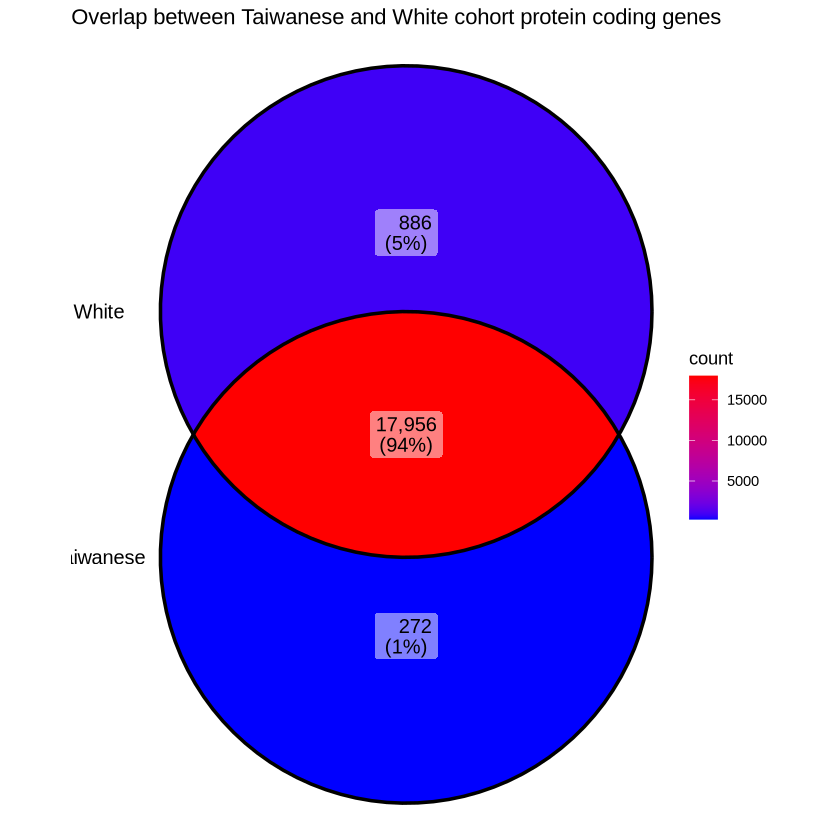

In [7]:
# Venn diagram of gene lists
taiwanese_genes <- colnames(taiwanese_expr)
white_genes <- colnames(white_expr)
listado <- list(Taiwanese = taiwanese_genes,
                 White = white_genes)
ggVennDiagram(listado)+
  scale_fill_gradient(low="blue", high = "red")+
  ggtitle("Overlap between Taiwanese and White cohort protein coding genes")


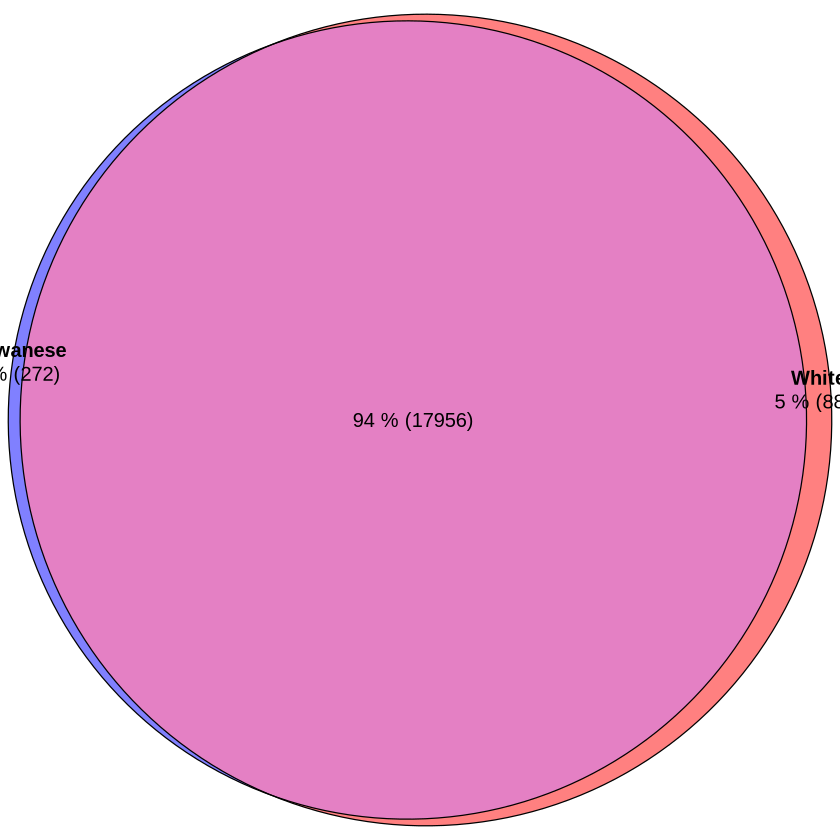

In [8]:
fit <- euler(list(Taiwanese = taiwanese_genes,
                 White = white_genes))
plot(fit, fills = list(fill = c("blue", "red"), alpha = 0.5), edges = list(col = "black"), quantities=list(fontsize = 12, type=c("percent", "counts")), labels = list(fontsize = 12))

In [9]:
taiwanese_mirnas <- readRDS("taiwanese_cohort/mirna_pooled_tmm/datExpr_clean.rds")
white_mirnas <- readRDS("cohort_white/newmirna_pooled/datExpr_clean.rds")

# pass taiwanese mirnas from name to ID
new_taiwanese <- miRNA_NameToAccession(colnames(taiwanese_mirnas), version = "v22")

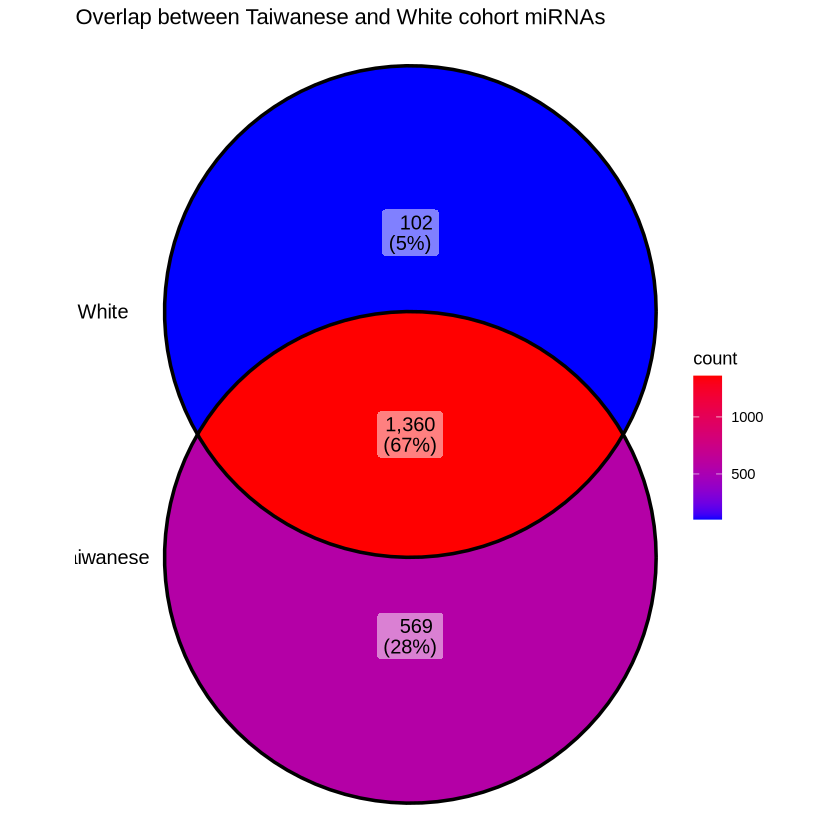

In [10]:
listado_mirna <- list(Taiwanese = new_taiwanese$Accession,
                      White = colnames(white_mirnas))

ggVennDiagram(listado_mirna)+
  scale_fill_gradient(low="blue", high = "red")+
  ggtitle("Overlap between Taiwanese and White cohort miRNAs")

In [11]:
# Load networks
taiwanese_path <- "taiwanese_cohort/count_matrices_by_geneid/ENCORI_filtered_edges_selected_modules_TAIWAN.tsv"
white_path <- "cohort_white/count_matrices_white_byFILENAME/ENCORI_filtered_edges_selected_modules_WHITE.tsv"

taiwanese_net <- read.table(taiwanese_path, sep="\t", header=TRUE)
white_net <- read.table(white_path, sep="\t", header=TRUE)

In [12]:
# also load differential expression table
de_taiwan_rna_path <- "taiwanese_cohort/count_matrices_by_geneid/DESeq2_RNA_results.tsv"
de_taiwan_mirna_path <- "taiwanese_cohort/count_matrices_by_geneid/DESeq2_miRNA_results.tsv"

de_white_rna_path <- "cohort_white/count_matrices_white_byFILENAME/DESeq2_RNA_results.tsv"
de_white_mirna_path <- "cohort_white/count_matrices_white_byFILENAME/DESeq2_miRNA_results.tsv"

taiwan_dernas <- read.table(de_taiwan_rna_path, header=TRUE, sep="\t", row.names=1)
taiwan_demirnas <- read.table(de_taiwan_mirna_path, header=TRUE, sep="\t", row.names=1)

white_dernas <- read.table(de_white_rna_path, header=TRUE, sep="\t", row.names=1)
white_demirnas <- read.table(de_white_mirna_path, header=TRUE, sep="\t", row.names=1)

In [13]:
# How many DEGs from TAIWAN
table(taiwan_dernas$Category)
# How many DEmiRNAs from TAIWAN
table(taiwan_demirnas$Category)

# How many DEGs from WHITE
table(white_dernas$Category)
# How many DEmiRNAs from WHITE
table(white_demirnas$Category)


 Down-regulated Not significant    Up-regulated 
            502           16742             984 


 Down-regulated Not significant    Up-regulated 
             20            1561              86 


 Down-regulated Not significant    Up-regulated 
            880           17087             875 


 Down-regulated Not significant    Up-regulated 
            118             936             153 

In [14]:
# correlate logFC of DEGs in both cohorts
# use all genes and color dots based on $Category
common_dernas <- intersect(rownames(taiwan_dernas), rownames(white_dernas))
taiwan_logFC <- taiwan_dernas[common_dernas, "log2FoldChange"]
white_logFC <- white_dernas[common_dernas, "log2FoldChange"]
cor(taiwan_logFC, white_logFC)

# make a plot of the correlation, color dots based on: significant in both, only in taiwan, only in white, none
df_logFC <- data.frame(Taiwan = taiwan_logFC, White = white_logFC)

svg("logFC_correlation_DEGs.svg")
ggplot(df_logFC, aes(x=Taiwan, y=White))+
  geom_point(alpha=0.5)+
  geom_smooth(method="lm", color="red")+
  ggtitle("Correlation of log2FC of DEGs in Taiwanese and White cohorts")+
  xlab("Taiwanese log2FC")+
  ylab("White log2FC")
dev.off()

[1] 0.7796841

`geom_smooth()` using formula = 'y ~ x'


pdf 
  2

In [15]:
# correlate logFC of DEmiRNAs in both cohorts
common_demirnas <- intersect(rownames(taiwan_demirnas), rownames(white_demirnas))
taiwan_logFC <- taiwan_demirnas[common_demirnas, "log2FoldChange"]
white_logFC <- white_demirnas[common_demirnas, "log2FoldChange"]
cor(taiwan_logFC, white_logFC)

# make a plot of the correlation, color dots based on: significant in both, only in taiwan, only in white, none
df_logFC <- data.frame(Taiwan = taiwan_logFC, White = white_logFC)
svg("logFC_correlation_DEmiRNAs.svg")
ggplot(df_logFC, aes(x=Taiwan, y=White))+
  geom_point(alpha=0.5)+
  geom_smooth(method="lm", color="red")+
  ggtitle("Correlation of log2FC of DEmiRNAs in Taiwanese and White cohorts")+
  xlab("Taiwanese log2FC")+
  ylab("White log2FC")
dev.off()

[1] 0.03081966

`geom_smooth()` using formula = 'y ~ x'


pdf 
  2

In [16]:
# intersection of DEGs between cohorts
taiwan_up <- rownames(taiwan_dernas)[taiwan_dernas$Category == "Up-regulated"]
white_up <- rownames(white_dernas)[white_dernas$Category == "Up-regulated"]
inter_up <- intersect(taiwan_up, white_up)
length(inter_up)
# now unique for taiwan and white
unique_taiwan_up <- setdiff(taiwan_up, white_up)
unique_white_up <- setdiff(white_up, taiwan_up)
length(unique_taiwan_up)
length(unique_white_up)

taiwan_down <- rownames(taiwan_dernas)[taiwan_dernas$Category == "Down-regulated"]
white_down <- rownames(white_dernas)[white_dernas$Category == "Down-regulated"]
inter_down <- intersect(taiwan_down, white_down)
length(inter_down)
# now unique for taiwan and white
unique_taiwan_down <- setdiff(taiwan_down, white_down)
unique_white_down <- setdiff(white_down, taiwan_down)
length(unique_taiwan_down)
length(unique_white_down)

[1] 445

[1] 539

[1] 430

[1] 266

[1] 236

[1] 614

In [17]:
# intersection of DEGs between cohorts
taiwan_up <- rownames(taiwan_demirnas)[taiwan_demirnas$Category == "Up-regulated"]
white_up <- rownames(white_demirnas)[white_demirnas$Category == "Up-regulated"]
inter_up <- intersect(taiwan_up, white_up)
length(inter_up)
# now unique for taiwan and white
unique_taiwan_up <- setdiff(taiwan_up, white_up)
unique_white_up <- setdiff(white_up, taiwan_up)
length(unique_taiwan_up)
length(unique_white_up)

taiwan_down <- rownames(taiwan_demirnas)[taiwan_demirnas$Category == "Down-regulated"]
white_down <- rownames(white_demirnas)[white_demirnas$Category == "Down-regulated"]
inter_down <- intersect(taiwan_down, white_down)
length(inter_down)
# now unique for taiwan and white
unique_taiwan_down <- setdiff(taiwan_down, white_down)
unique_white_down <- setdiff(white_down, taiwan_down)
length(unique_taiwan_down)
length(unique_white_down)

[1] 6

[1] 80

[1] 147

[1] 2

[1] 18

[1] 116

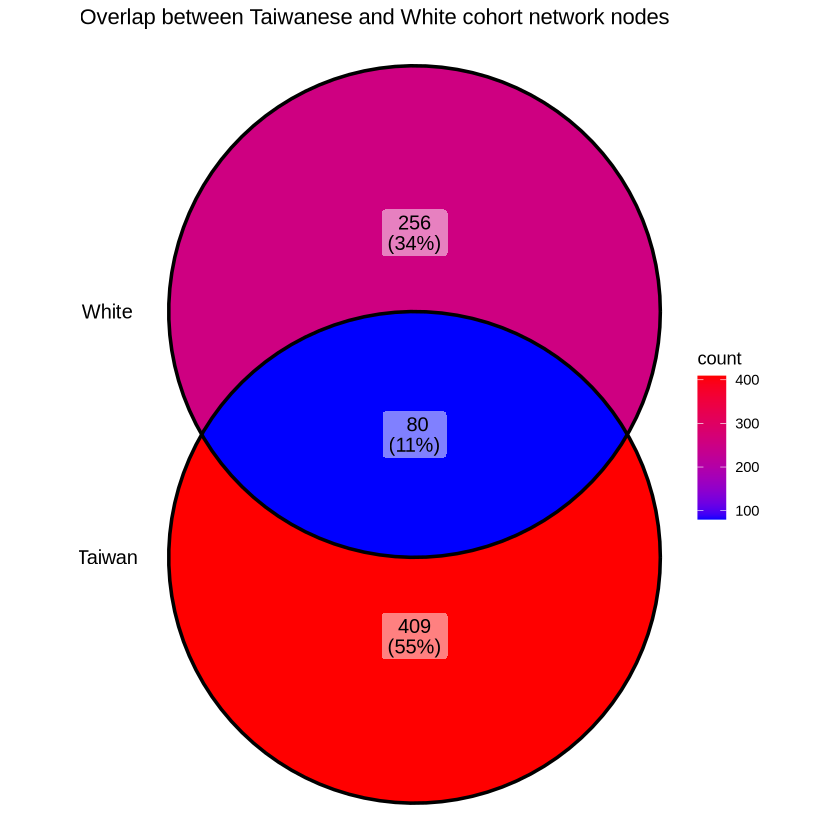

In [18]:
nodes_mirna_taiwan <- unique(taiwanese_net$miRNAid)
nodes_rna_taiwan <- unique(taiwanese_net$geneID)

nodes_taiwan <- union(nodes_mirna_taiwan, nodes_rna_taiwan)

nodes_mirna_white <- unique(white_net$miRNAid)
nodes_rna_white <- unique(white_net$geneID)

nodes_white <- union(nodes_mirna_white, nodes_rna_white)

listado_nodes <- list(Taiwan = nodes_taiwan,
                      White = nodes_white)
ggVennDiagram(listado_nodes)+
  scale_fill_gradient(low="blue", high = "red")+
  ggtitle("Overlap between Taiwanese and White cohort network nodes")

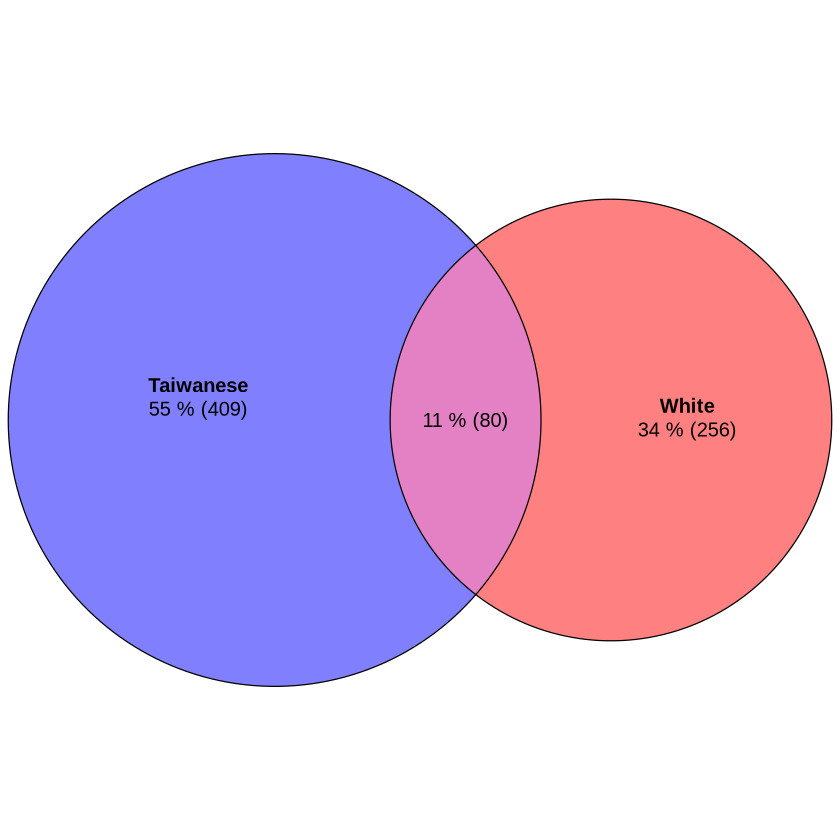

In [19]:
fit <- euler(list(Taiwanese = nodes_taiwan,
                 White = nodes_white))
plot(fit, fills = list(fill = c("blue", "red"), alpha = 0.5), edges = list(col = "black"), quantities=list(fontsize = 12, type=c("percent", "counts")), labels = list(fontsize = 12))

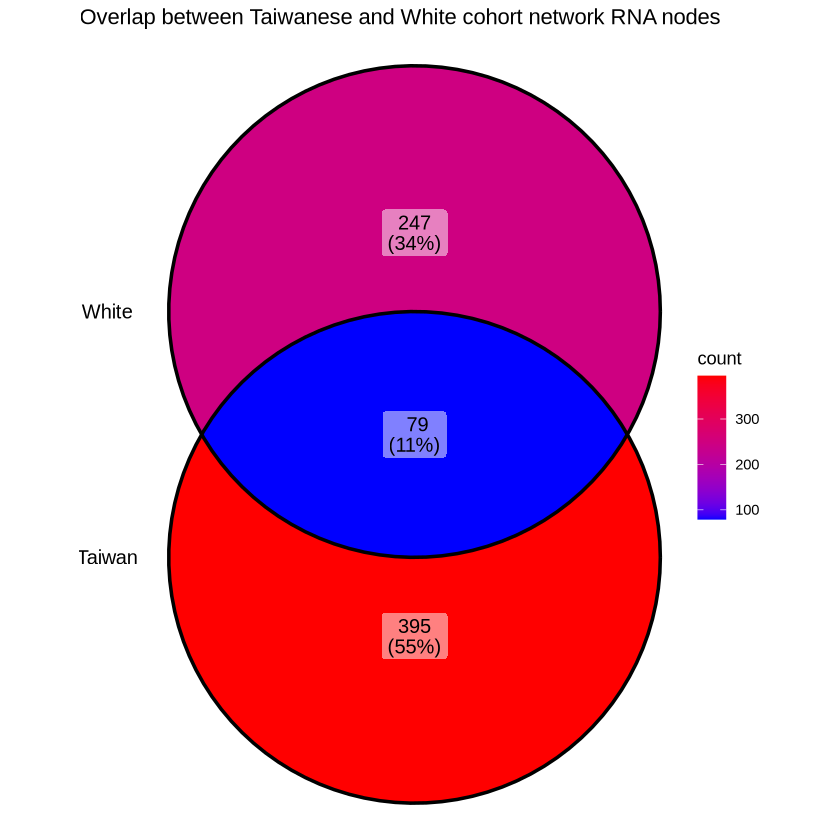

In [20]:
listado_nodes_rna <- list(Taiwan = nodes_rna_taiwan,
                      White = nodes_rna_white)
ggVennDiagram(listado_nodes_rna)+
  scale_fill_gradient(low="blue", high = "red")+
  ggtitle("Overlap between Taiwanese and White cohort network RNA nodes")

In [21]:
fit <- euler(list(Taiwanese = nodes_rna_taiwan,
                 White = nodes_rna_white))

svg()
plot(fit, fills = list(fill = c("blue", "red"), alpha = 0.5), edges = list(col = "black"), quantities=list(fontsize = 12, type=c("percent", "counts")), labels = list(fontsize = 12))
dev.off()

pdf 
  2

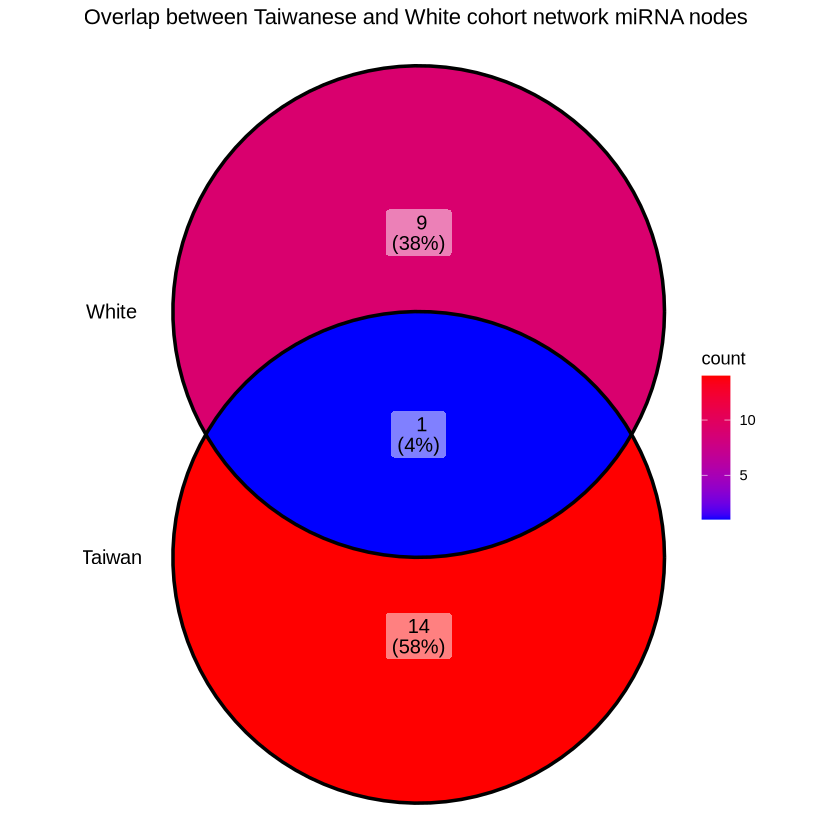

In [22]:
listado_nodes_mirna <- list(Taiwan = nodes_mirna_taiwan,
                      White = nodes_mirna_white)
ggVennDiagram(listado_nodes_mirna)+
  scale_fill_gradient(low="blue", high = "red")+
  ggtitle("Overlap between Taiwanese and White cohort network miRNA nodes")

In [23]:
fit <- euler(list(Taiwanese = nodes_mirna_taiwan,
                 White = nodes_mirna_white))
svg()
plot(fit, fills = list(fill = c("blue", "red"), alpha = 0.5), edges = list(col = "black"), quantities=list(fontsize = 12, type=c("percent", "counts")), labels = list(fontsize = 12))
dev.off()

pdf 
  2

In [24]:
intersect(nodes_mirna_taiwan, nodes_mirna_white)

[1] "MIMAT0000250"

In [25]:
g_taiwan <- graph_from_data_frame(taiwanese_net[, c("miRNAid", "geneID", "weight")], directed=TRUE)
g_white <- graph_from_data_frame(white_net[, c("miRNAid", "geneID", "weight")], directed=TRUE)

In [26]:
stats_taiwan <- calcular_topologia(g_taiwan, "Taiwanese Network")
stats_white <- calcular_topologia(g_white, "White Network")
stats <- rbind(stats_taiwan, stats_white)
stats

Red,Num_Nodos,Num_Aristas,Densidad,Clustering_Coef,Grado_Promedio,Diametro
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Taiwanese Network,489,1187,0.004974186,0,4.854806,7
White Network,336,498,0.004424307,0,2.964286,5


In [27]:
edges_taiwan <- as_ids(E(g_taiwan))
edges_white <- as_ids(E(g_white))

intersection <- length(intersect(edges_taiwan, edges_white))
union <- length(union(edges_taiwan, edges_white))
jaccard <- intersection/union
jaccard

[1] 0.008378217

In [28]:
taiwan_lost <- setdiff(edges_taiwan, edges_white)
taiwan_gained <- setdiff(edges_white, edges_taiwan)

length(taiwan_lost)
length(taiwan_gained)

[1] 1173

[1] 484

In [29]:
# IDEA: ONLY DO ENRICHMENT ON THE GENES THAT ARE UNIQUE TO EACH NETWORK
nodes_taiwan_unique <- setdiff(nodes_rna_taiwan, nodes_rna_white)
nodes_white_unique <- setdiff(nodes_rna_white, nodes_rna_taiwan)
length(nodes_taiwan_unique)
length(nodes_white_unique)

[1] 395

[1] 247

In [30]:
# Enrichment on the taiwanese nodes
ego_taiwan <- enrichGO(gene         = nodes_taiwan_unique,
                OrgDb        = org.Hs.eg.db,
                keyType      = "ENSEMBL",
                ont          = "BP",
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.01,
                qvalueCutoff  = 0.05,
                readable      = TRUE)

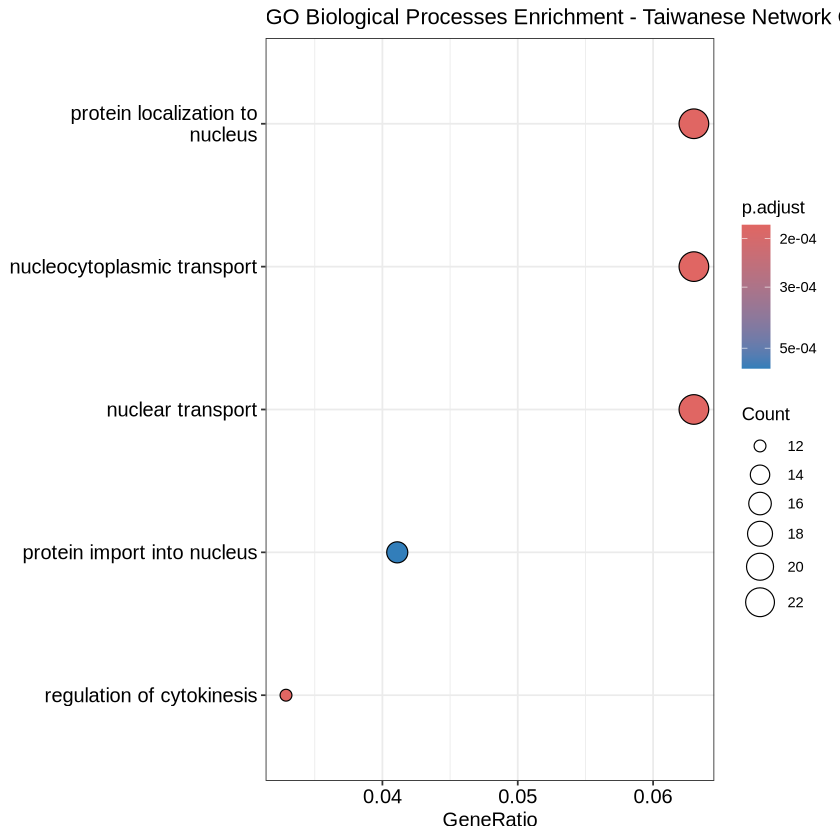

In [31]:
# visualize the enrichment
dotplot(ego_taiwan, showCategory=5) + ggtitle("GO Biological Processes Enrichment - Taiwanese Network Genes")

In [32]:
# enrichment on the white nodes
ego_white <- enrichGO(gene = nodes_white_unique,
                OrgDb        = org.Hs.eg.db,
                keyType      = "ENSEMBL",
                ont          = "BP",
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.01,
                qvalueCutoff  = 0.05,
                readable      = TRUE)

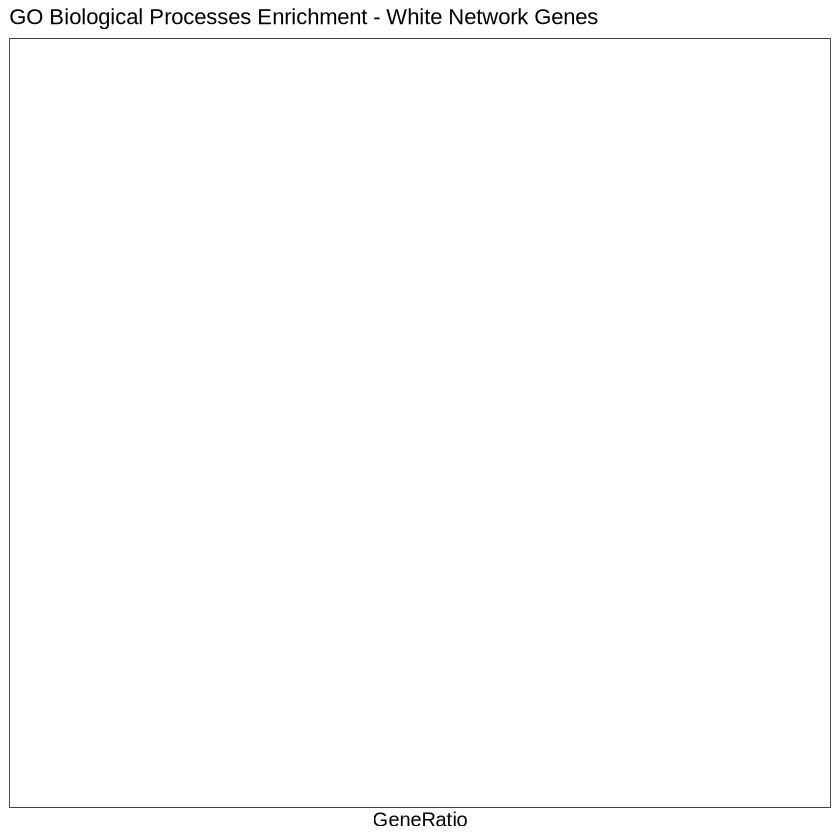

In [33]:
# visualize the enrichment
dotplot(ego_white, showCategory=5) + ggtitle("GO Biological Processes Enrichment - White Network Genes")

In [34]:
V(g_taiwan)$degree <- degree(g_taiwan, mode="in")
V(g_taiwan)$type <- ifelse(grepl("MIMAT", V(g_taiwan)$name), "miRNA", "gene")

gene_stats <- data.frame(
    ID = V(g_taiwan)$name,
    Type = V(g_taiwan)$type,
    Degree = V(g_taiwan)$degree
) %>% filter(Type == "gene")

In [35]:
svg("degree_distribution_taiwan.svg")
ggplot(gene_stats, aes(x=Degree))+
  geom_histogram(binwidth=1, fill="blue", color="black")+
  ggtitle("Degree distribution of gene nodes in Taiwanese network")+
  xlab("Degree")+
  ylab("Frequency")
dev.off()

pdf 
  2

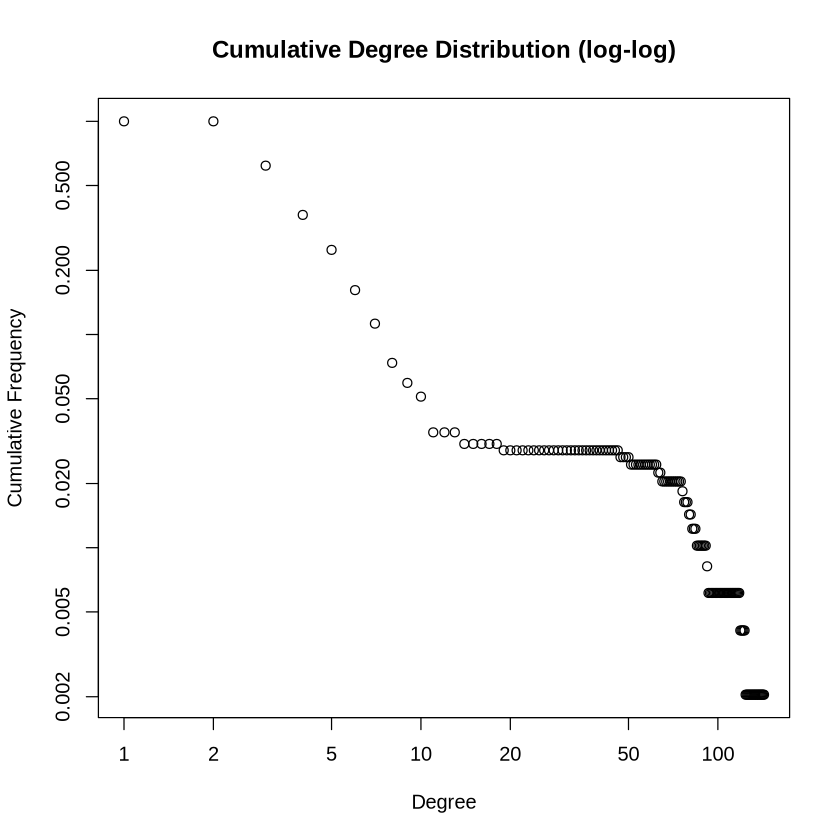

In [36]:
deg_dist <- degree_distribution(g_taiwan, cumulative=TRUE)
plot(deg_dist, log="xy", main="Cumulative Degree Distribution (log-log)", xlab="Degree", ylab="Cumulative Frequency")

In [37]:
V(g_white)$degree <- degree(g_white, mode="in")
V(g_white)$type <- ifelse(grepl("MIMAT", V(g_white)$name), "miRNA", "gene")

gene_stats <- data.frame(
    ID = V(g_white)$name,
    Type = V(g_white)$type,
    Degree = V(g_white)$degree
) %>% filter(Type == "gene")

In [38]:
svg("degree_distribution_white.svg")
ggplot(gene_stats, aes(x=Degree))+
  geom_histogram(binwidth=1, fill="blue", color="black")+
  ggtitle("Degree distribution of gene nodes in White network")+
  xlab("Degree")+
  ylab("Frequency")
dev.off()

pdf 
  2

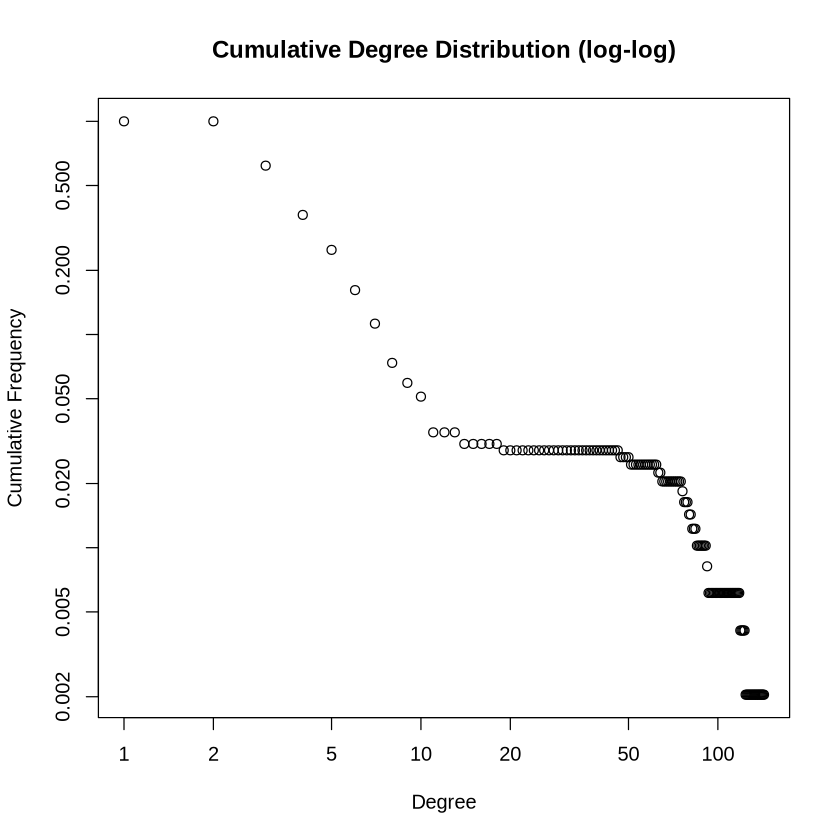

In [39]:
deg_dist <- degree_distribution(g_taiwan, cumulative=TRUE)
plot(deg_dist, log="xy", main="Cumulative Degree Distribution (log-log)", xlab="Degree", ylab="Cumulative Frequency")

In [40]:
# load the top 1000 genes and miRNAs from each network and compare them
top_genes_taiwan <- read.table("taiwanese_cohort/count_matrices_by_geneid/top_genes.txt", header=F, sep="\t")
top_genes_white <- read.table("cohort_white/count_matrices_white_byFILENAME/top_genes.txt", header=F, sep="\t")

top_mirnas_taiwan <- read.table("taiwanese_cohort/count_matrices_by_geneid/top_mirnas.txt", header=F, sep="\t") 
top_mirnas_white <- read.table("cohort_white/count_matrices_white_byFILENAME/top_mirnas.txt", header=F, sep="\t")

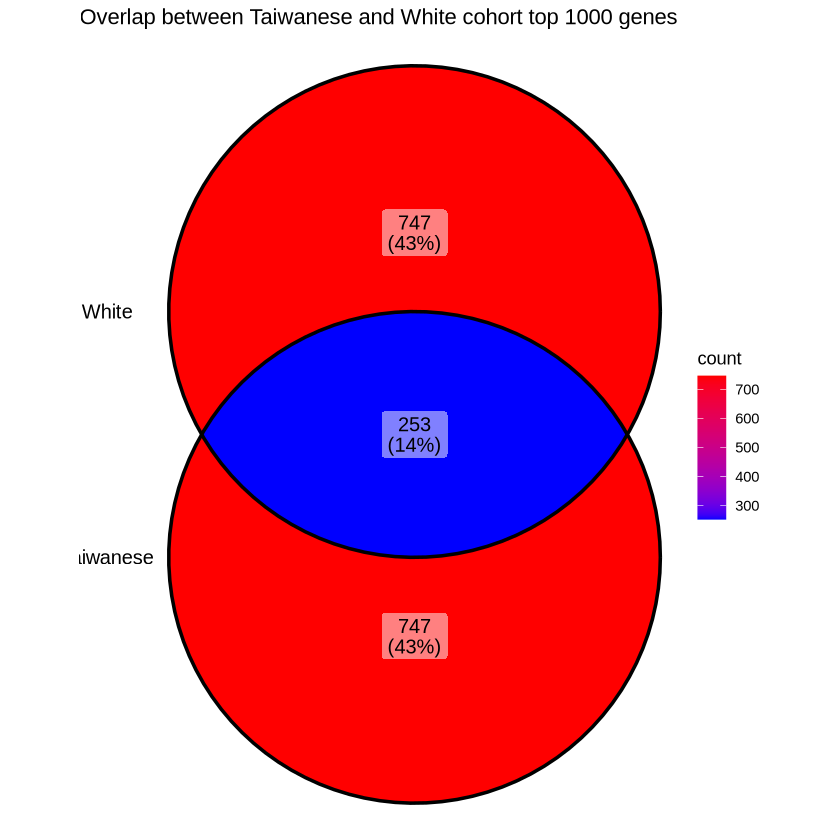

In [41]:
# Venn diagram between top 1000 genes
listado_top_genes <- list(Taiwanese = top_genes_taiwan$V1,
                      White = top_genes_white$V1)
ggVennDiagram(listado_top_genes)+
  scale_fill_gradient(low="blue", high = "red")+
  ggtitle("Overlap between Taiwanese and White cohort top 1000 genes")

In [42]:
# pass taiwan mirnas to MIMATs before comparing with white
new_taiwanese <- miRNA_NameToAccession(top_mirnas_taiwan$V1, version = "v22")
new_taiwanese <- new_taiwanese$Accession

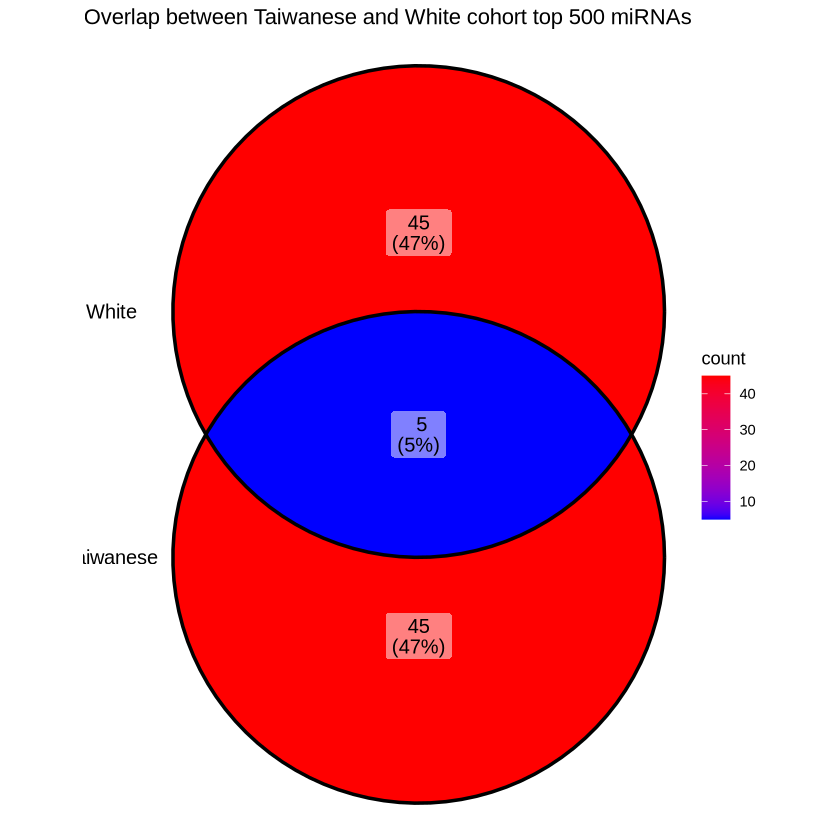

In [43]:
# venn diagram of top mirnas
listado_top_mirnas <- list(Taiwanese = new_taiwanese,
                      White = top_mirnas_white$V1)
ggVennDiagram(listado_top_mirnas)+
  scale_fill_gradient(low="blue", high = "red")+
  ggtitle("Overlap between Taiwanese and White cohort top 500 miRNAs")